# Statistical Analysis & A/B Testing Project

In [1]:
from math import ceil


import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.stats.api as sms
from statsmodels.stats import weightstats as stests
from statsmodels.stats.proportion import proportions_ztest, proportion_confint


%matplotlib inline


## 1. Аналіз великих вибірок (Z-test)

**Контекст:**

Компанія хоче перевірити, чи середня сума покупки (середній чек) у липні 2025 року статистично значуще збільшилася порівняно із середнім історичним значенням у $20.

**Дані:**

- Набір даних: покупки в липні 2025
- Історичне значення середнього чеку: $20
- Рівень значущості: α =0.05
- Метод: z-test


In [2]:
# Завантаження даних
data = pd.read_csv('D:/DATAS/Python/data/data.csv')

# Перевірка даних
data = data.data.values
data.shape

(100,)

## Крок 1: Manual Z-test Calculation

Перш ніж використати готові інструменти, необхідно виконати обчислення вручну, використовуючи бібліотеки **numpy** та **scipy.stats**.  
Це дозволить краще зрозуміти механіку тесту та перевірити, чи середній чек у липні 2025 року статистично значущо відрізняється від історичного рівня $20.  

**План:**
- задати основні параметри вибірки (середнє, стандартне відхилення, розмір вибірки);  
- сформулювати гіпотези;  
- обчислити стандартну помилку та z-статистику;  
- знайти критичне значення та p-value;  
- зробити висновок щодо відхилення або прийняття нульової гіпотези.  


**1. Записую параметри у змінні:**

In [3]:
sample_mean = np.mean(data)                      # середнє значення у вибірці
population_mean = 20                             # середнє значення у популяції (історичне за умовою задачі)      
population_std = np.std(data, ddof=1)            # вибіркове стандартне відхилення
sample_size = len(data)                          # розмір вибірки
alpha = 0.05                                     # рівень значущості (за умовою задачі)

**2. Формулюю гіпотези та визначаю вид тесту:**
   - Нульова гіпотеза $Hо$ : середній чек у липні 2025 року залишився як в минулих місяцях і складає 20 доларів - $\mu_о$ = 20.
   - Альтернативна гіпотеза $Ha$ : середній чек у липні збільшився - $\mu_а$ > 20.
   - Це правосторонній тест.

**3. Обчислюю стандартну помилку SE:**

In [4]:
standard_error = population_std / np.sqrt(sample_size)

print("Формула: SE = σ / √n")
print()
print(f"SE = {population_std:.2f} / √{sample_size}")
print(f"SE = {population_std:.2f} / {np.sqrt(sample_size):.0f}")
print(f"SE = {standard_error:.3f}")
print()
print("Висновок: В середньому, вибіркове середнє відхиляється")
print(f"від справжнього середнього на ±{standard_error:.3f} доларів")

Формула: SE = σ / √n

SE = 6.25 / √100
SE = 6.25 / 10
SE = 0.625

Висновок: В середньому, вибіркове середнє відхиляється
від справжнього середнього на ±0.625 доларів


**4. Розраховую z-статистику:**

In [5]:
z_statistic = (sample_mean - population_mean) / standard_error

print("Формула: z = (x̄ - μ₀) / SE")
print()
print(f"z = ({sample_mean:.2f} - {population_mean}) / {standard_error:.3f}")
print(f"z = {sample_mean - population_mean:.2f} / {standard_error:.3f}")
print(f"z = {z_statistic:.3f}")
print()
print("Висновок:")
print(f"Вибіркове середнє відхиляється на {z_statistic:.3f} стандартних помилок")
print("від гіпотетичного середнього популяції.")
print()
if z_statistic > 3:
    print("Це дуже велике відхилення (більше 3 стандартних помилок).")
elif z_statistic > 2:
    print("Це велике відхилення (між 2 та 3 стандартними помилками).")
elif z_statistic > 1:
    print("Це помірне відхилення (між 1 та 2 стандартними помилками).")
else:
    print("Це невелике відхилення (менше 1 стандартної помилки).")

Формула: z = (x̄ - μ₀) / SE

z = (19.38 - 20) / 0.625
z = -0.62 / 0.625
z = -0.995

Висновок:
Вибіркове середнє відхиляється на -0.995 стандартних помилок
від гіпотетичного середнього популяції.

Це невелике відхилення (менше 1 стандартної помилки).


**5. Шукаю критичне z-значення:**

In [6]:
# Для правостороннього тесту з α = 0.05
z_critical = stats.norm.ppf(1 - alpha)

print(f"Для рівня значущості α = {alpha} (для правостороннього тесту):")
print(f"критичне z-значення з таблиці = {z_critical:.3f}")
print()
print(f"Якщо z-статистика > {z_critical:.3f}, то результат настільки незвичайний,")
print("що ми не віримо у випадковість за гіпотезою Но.")
print(f"Ймовірність отримати z > {z_critical:.3f} випадково = {alpha*100}%")

Для рівня значущості α = 0.05 (для правостороннього тесту):
критичне z-значення з таблиці = 1.645

Якщо z-статистика > 1.645, то результат настільки незвичайний,
що ми не віримо у випадковість за гіпотезою Но.
Ймовірність отримати z > 1.645 випадково = 5.0%


**6. Обчислюю p-value:**

In [7]:
# Для правостороннього тесту: p-value = P(Z > z_statistic)
p_value = 1 - stats.norm.cdf(z_statistic)

print(f"p-value = {p_value:.2f}")
print()
print(f"Якщо гіпотеза H₀ правдива (середній чек у липні 2025 року так і залишається 20 доларів), ")
print(f"то ймовірність випадково отримати середнє значення чеку ≥ {sample_mean:.2f} становить {p_value:.2f} або приблизно {p_value*100:.2f}%.")
print()
if p_value < 0.001:
    print("Це НАДЗВИЧАЙНО малоймовірно! (менше 0.1%).")
elif p_value < 0.01:
    print("Це дуже малоймовірно! (менше 1%).")
elif p_value < 0.05:
    print("Це малоймовірно! (менше 5%).")
else:
    print("Це цілком можливо випадково.")

p-value = 0.84

Якщо гіпотеза H₀ правдива (середній чек у липні 2025 року так і залишається 20 доларів), 
то ймовірність випадково отримати середнє значення чеку ≥ 19.38 становить 0.84 або приблизно 84.02%.

Це цілком можливо випадково.


**7. Приймаю рішення чи варто відхиляти гіпотезу $H_о$:**
- Метод 1: Порівняння z-статистики з критичним значенням:

In [8]:
print(f"z-статистика = {z_statistic:.3f}")
print(f"Критичне значення = {z_critical:.3f}")
print(f"Порівняння: {z_statistic:.3f} {'>' if z_statistic > z_critical else '≤'} {z_critical:.3f}")

if z_statistic > z_critical:
    print("Висновок: z-статистика ПЕРЕВИЩУЄ критичне значення.")
    decision1 = "ВІДХИЛЯЄМО H₀."
else:
    print("Висновок: z-статистика НЕ перевищує критичне значення.")
    decision1 = "НЕ ВІДХИЛЯЄМО H₀."

print(f"Рішення: {decision1}")

z-статистика = -0.995
Критичне значення = 1.645
Порівняння: -0.995 ≤ 1.645
Висновок: z-статистика НЕ перевищує критичне значення.
Рішення: НЕ ВІДХИЛЯЄМО H₀.


 - Метод 2: Порівняння p-value з рівнем значущості (p-value дає точну ймовірність):

In [9]:
print(f"p-value = {p_value:.2f}")
print(f"Рівень значущості α = {alpha}")
print(f"Порівняння: {p_value:.2f} {'<' if p_value < alpha else '≥'} {alpha}")

if p_value < alpha:
    print("Висновок: p-value МЕНШЕ за рівень значущості.")
    decision2 = "ВІДХИЛЯЄМО H₀."
else:
    print("Висновок: p-value НЕ менше за рівень значущості.")
    decision2 = "НЕ ВІДХИЛЯЄМО H₀."

print(f"Рішення: {decision2}")

p-value = 0.84
Рівень значущості α = 0.05
Порівняння: 0.84 ≥ 0.05
Висновок: p-value НЕ менше за рівень значущості.
Рішення: НЕ ВІДХИЛЯЄМО H₀.


**Висновок:**

Завдяки двом незалежним способам перевірки, через z‑статистику та p‑value, підтвердилось одне й те саме:
- z‑статистика = -0.995 показує, що вибіркове середнє навіть трохи менше за історичне, і відхилення менше за критичне значення z_critical=1.645.
- p‑value = 0.84 значно перевищує рівень значущості $\alpha$ =0.05, тобто ймовірність отримати такі дані при $H₀$ дуже велика.

**Не відхиляємо $H₀$.** Це означає, що статистично значущого підвищення середнього чеку у липні 2025 року не відбулося, тому середній чек залишився на рівні близько 20 доларів, як і в попередні місяці 2025 року.


## Крок 2: Z-test with statsmodels

На попередньому етапі були виконані обчислення вручну.  
Тепер варто перевірити гіпотези за допомогою бібліотеки **statsmodels**, щоб отримати z-статистику та p-value автоматично.  

**Мета:** 
- Перевірити, чи є достатньо статистичних доказів, щоб стверджувати, що середній чек у липні 2025 року зріс порівняно з історичним рівнем $20.  
- Порівняти отримані значення з попередніми розрахунками вручну та переконатися, що результати збігаються.  

In [10]:
# Правосторонній z-тест
z_stat_sm, p_val_sm = stests.ztest(data,                   
                                   value=population_mean,  # μ₀ = 20
                                   alternative='larger')   # H₁: μа > 20

print(f"Результати z-тесту:")
print(f"  Z-статистика: {z_stat_sm:.3f}")
print(f"  P-value: {p_val_sm:.2f}")

# Інтерпретація результатів
print("Висновок:")
if p_val_sm < alpha:
    print(f"  ВІДХИЛЯЄМО H₀.")
    print(f"  p-value ({p_val_sm:.2f}) < α ({alpha})")
    print("  Середній чек у липні 2025 року виріс порівняно з іншими місяцями.")
else:
    print(f"  НЕ ВІДХИЛЯЄМО H₀.")
    print(f"  p-value ({p_val_sm:.2f}) ≥ α ({alpha})")
    print("  Статистично значущого підвищення середнього чеку у липні 2025 року не відбулося.")
print()
print("Порівняння з ручними розрахунками:")
print(f"Z-статистика:")
print(f"  Ручний розрахунок: {z_statistic:.3f}")
print(f"  Statsmodels:       {z_stat_sm:.3f}")
print(f"  Різниця:           {abs(z_statistic - z_stat_sm):.3f}")
print()
print("Висновок: різниці між ручними розрахунками та обчисленнями з використанням бібліотеки statsmodels немає.")

Результати z-тесту:
  Z-статистика: -0.995
  P-value: 0.84
Висновок:
  НЕ ВІДХИЛЯЄМО H₀.
  p-value (0.84) ≥ α (0.05)
  Статистично значущого підвищення середнього чеку у липні 2025 року не відбулося.

Порівняння з ручними розрахунками:
Z-статистика:
  Ручний розрахунок: -0.995
  Statsmodels:       -0.995
  Різниця:           0.000

Висновок: різниці між ручними розрахунками та обчисленнями з використанням бібліотеки statsmodels немає.


**Була розглянута робота з великими даними, де працює закон великих чисел. Однак на практиці аналітик часто стикається з обмеженими вибірками. У наступному розділі перевірятиметься, як змінюється підхід, коли є дані лише про 7 користувачів.**

## 2. Тести для малих вибірок та пропорцій (T-test)

## Кейс 1: Time-to-Purchase After Website Redesign

**Контекст:**  
E-commerce компанія провела редизайн сайту і хоче перевірити, чи середній час до покупки (time-to-purchase) користувачів збільшився.  
Історично середній час становив μ₀ = 123.7 хвилин.  

**Дані:**  
Випадково обрано дані 7 покупців після редизайну:  
`128, 135, 121, 142, 126, 151, 123`  

**Мета аналізу:**  
Перевірити статистично, чи середній час до покупки зріс після редизайну. Для цього необхідно застосувати t-test для малої вибірки на рівні значущості α = 0.10.  

**План:**  
1. Сформулювати нульову та альтернативну гіпотези.  
2. Обчислити вибіркові статистики (середнє, стандартне відхилення, розмір вибірки).  
3. Виконати t-test, отримати критичне значення, статистику тесту та p-value.  
4. Прийняти рішення щодо H₀ на основі p-value.  
5. Зробити висновок: чи справді редизайн подовжив час до покупки.  
6. Перевірити, чи зміниться рішення при α = 0.05.  


**1. Визначаю нульову та альтернативну гіпотези та тип тесту:**

- Нульова гіпотеза $H_о$ : середній час від першого заходу на сайт до покупки становить 123.7 хвилин - $\mu_о$ = 123.7.
- Альтернативна гіпотеза $H_a$ : середній час до покупки збільшився - $\mu_a$ > 123.7.
- Це правосторонній тест.

**2. Обчислюю вибіркові статистики: $\bar x$, $s$, $n$:**

In [11]:
# Дані з умови (вибірка після редизайну)
time = np.array([128, 135, 121, 142, 126, 151, 123])
mu0 = 123.7   # середній час до покупки
alpha = 0.10

# Обчислення вибіркової статистики
x_bar = np.mean(time)
s = np.std(time, ddof=1)
n = len(time)

# Вивід результатів
print(f"Вибіркове середнє: {x_bar:.2f}")
print(f"Вибіркове стандартне відхилення: {s:.2f}")
print(f"Розмір вибірки: {n}")

Вибіркове середнє: 132.29
Вибіркове стандартне відхилення: 10.98
Розмір вибірки: 7


**3. Шукаю статистику тесту, критичне значення тесту та р-value:**

In [12]:
# Обчислення t-статистику
t_stat = (x_bar - mu0) / (s / np.sqrt(n))

# Критичне значення для правостороннього тесту
df = n - 1
t_crit = stats.t.ppf(1 - alpha, df)

# Обчислення p-value
p_value = 1 - stats.t.cdf(t_stat, df)


# Вивід результатів
print(f"t-статистика: {t_stat:.3f}")
print(f"Критичне значення (df={df}): {t_crit:.3f}")
print(f"Порівняння: {t_stat:.3f} {'<' if t_stat < t_crit else '≥'} {t_crit:.3f}")

# Висновок
if t_stat > t_crit:
    print("Висновок: t-статистика ПЕРЕВИЩУЄ критичне значення.")
    decision1 = "ВІДХИЛЯЄМО H₀: середній час до покупки збільшився на рівні значущості 0.1."
else:
    print("Висновок: t-статистика НЕ перевищує критичне значення.")
    decision1 = "НЕ ВІДХИЛЯЄМО H₀."

print(f"Рішення: {decision1}")

t-статистика: 2.069
Критичне значення (df=6): 1.440
Порівняння: 2.069 ≥ 1.440
Висновок: t-статистика ПЕРЕВИЩУЄ критичне значення.
Рішення: ВІДХИЛЯЄМО H₀: середній час до покупки збільшився на рівні значущості 0.1.


**4. Роблю висновок щодо відхилення нульової гіпотези $H_0$ використовуючи p-value:**

In [13]:
print(f"p-value = {p_value:.4f}")
print(f"Рівень значущості α = {alpha}")
print(f"Порівняння: {p_value:.4f} {'<' if p_value < alpha else '≥'} {alpha}")

if p_value < alpha:
    print("Висновок: p-value МЕНШЕ за рівень значущості.")
    decision2 = "ВІДХИЛЯЄМО H₀: середній час до покупки збільшився на рівні значущості 0.1."
else:
    print("Висновок: p-value НЕ менше за рівень значущості.")
    decision2 = "НЕ ВІДХИЛЯЄМО H₀."

print(f"Рішення: {decision2}")

p-value = 0.0420
Рівень значущості α = 0.1
Порівняння: 0.0420 < 0.1
Висновок: p-value МЕНШЕ за рівень значущості.
Рішення: ВІДХИЛЯЄМО H₀: середній час до покупки збільшився на рівні значущості 0.1.


  **5. Загальний висновок:**

Завдяки двом незалежним способам перевірки, через прорахунок t‑статистики та p‑value, підтвердилось одне й те саме:

- t‑статистика = 2.069 означає, що вибіркове середнє більше за історичне, і відхилення більше за критичне значення t_crit=1.440.
- p‑value = 0.0420 НЕ перевищує рівень значущості $\alpha = 0.10$, тобто то ймовірність отримати такі дані при $H_о$ дуже мала.

**Відхиляємо нульову гіпотезу $H_о$**. Це означає, що середній час до покупки статистично значущо збільшився на рівні значущості 0.1.

**6. Роблю перевірку стосовно зміни рішення і висновків при зміні рівня значущості на $\alpha = 0.05$ на основі порівняння з p-value.**

In [14]:
alpha_alt = 0.05

print(f"p-value = {p_value:.4f}")
print(f"Рівень значущості α = {alpha_alt}")
print(f"Порівняння: {p_value:.4f} {'<' if p_value < alpha_alt else '≥'} {alpha_alt}")

if p_value < alpha_alt:
    print("Висновок: p-value МЕНШЕ за рівень значущості.")
    decision2 = "ВІДХИЛЯЄМО H₀: середній час до покупки збільшився на рівні значущості 0.05."
else:
    print("Висновок: p-value НЕ менше за рівень значущості.")
    decision2 = "НЕ ВІДХИЛЯЄМО H₀."

print(f"Рішення: {decision2}")

p-value = 0.0420
Рівень значущості α = 0.05
Порівняння: 0.0420 < 0.05
Висновок: p-value МЕНШЕ за рівень значущості.
Рішення: ВІДХИЛЯЄМО H₀: середній час до покупки збільшився на рівні значущості 0.05.


**Висновок:**

p‑value = 0.042 все одно НЕ перевищує новий рівень значущості $\alpha = 0.05$, тобто на рівні значущості 5% є статистично значущі докази того, що після редизайну сайту середній час до покупки збільшився.
Тож **відхиляємо нульову гіпотезу $H_о$**. 

Але сила доказів залежить саме від обраного рівня значущості. При більш серйозній зміні, наприклад, на $\alpha = 0.01$, доказів було б недостатньо і нульова гіпотеза не відхилялася.

## Кейс 2: Logo Recognition After Marketing Campaign

**Контекст:**  
До рекламної кампанії 23% дорослих упізнавали логотип компанії.  
Після кампанії проведено опитування: серед 1200 випадково відібраних дорослих 311 упізнали логотип.  

**Мета аналізу:**  
Перевірити, чи зросла впізнаваність логотипу після кампанії. Для цього необхідно застосувати пропорційний z-test на рівні значущості 3% (α = 0.03).  

**План:**  
1. Сформулювати гіпотези:  
   - H₀: p = 0.23 (частка впізнаваності не зросла)  
   - H₁: p > 0.23 (частка впізнаваності зросла)  
2. Виконати тест за допомогою бібліотеки **statsmodels**.  
3. Отримати z-статистику та p-value.  
4. Прийняти рішення щодо H₀.  
5. Обчислити довірчий інтервал для пропорції на рівні α = 0.03.  
6. Інтерпретувати інтервал та пояснити, як він підтверджує або уточнює рішення. 

**Визначаю нульову та альтернативну гіпотези та тип тесту:**

- Нульова гіпотеза $H_о$ : частка дорослих, які впізнають логотип, залишилась на рівні 23% - $p_o$ = 0,23.
- Альтернативна гіпотеза $H_a$ : середній час до покупки збільшився - $p_a$ > 0,23.
- Це правосторонній тест пропорцій.

In [15]:
count = 311       # кількість "успіхів"
nobs = 1200       # обсяг вибірки
p0 = 0.23         # гіпотетична пропорція (Ho)
alpha2 = 0.03     # рівень значущості

# z-тест для пропорції
stat, pval = proportions_ztest(count, nobs, p0, alternative='larger')
confint = proportion_confint(count, nobs, alpha2, method='normal')

print("Тест для однієї пропорції:")
print(f"Z-статистика = {stat:.3f}")
print(f"p-value = {pval:.4f}")
print(f"95% довірчий інтервал: {confint}")
print(f"Рівень значущості α = {alpha2}")
print(f"Порівняння: {pval:.4f} {'<' if pval < alpha2 else '≥'} {alpha2}")

if pval < alpha2:
    print("Висновок: p-value МЕНШЕ за рівень значущості.")
    decision3 = "ВІДХИЛЯЄМО H₀: є статистично значущі докази того, що впізнаваність логотипу зросла понад 23%."
else:
    print("Висновок: p-value НЕ менше за рівень значущості.")
    decision3 = "НЕ ВІДХИЛЯЄМО H₀."

print(f"Рішення: {decision3}")

Тест для однієї пропорції:
Z-статистика = 2.306
p-value = 0.0106
95% довірчий інтервал: (0.23171700302179205, 0.28661633031154127)
Рівень значущості α = 0.03
Порівняння: 0.0106 < 0.03
Висновок: p-value МЕНШЕ за рівень значущості.
Рішення: ВІДХИЛЯЄМО H₀: є статистично значущі докази того, що впізнаваність логотипу зросла понад 23%.


**Висновок по довірчому інтервалу:**
95% довірчий інтервал для пропорції впізнаваності логотипу знаходиться в межах (0.232, 0.287).
Оскільки весь інтервал лежить вище порогового значення 0.23, можна стверджувати, що з імовірністю 95% справжній рівень впізнаваності вище 23%.

**Навченої методології перевірки гіпотез достатньо для базових тестів. Можна застосувати ці знання до реального бізнес-кейсу - A/B тесту мобільної гри Cookie Cats, де буде проаналізовано утримання гравців (Retention) за допомогою Bootstrap та Хі-квадрат тесту.**

## 3. Комплексний аналіз A/B тесту: Cookie Cats
**Контекст:**  
Cookie Cats - популярна мобільна гра-головоломка у стилі «з’єднай три». У грі є спеціальні ворота, які зупиняють прогрес гравця та стимулюють його або зачекати, або зробити покупку.  
Команда розробників вирішила провести A/B тест: перемістити перші ворота з рівня 30 на рівень 40 та перевірити, як це вплине на утримання гравців (retention).  

**Дані:**  
Файл `cookie_cats.csv` містить інформацію про гравців:  
- `userid` - унікальний ідентифікатор гравця  
- `version` - група тесту (gate_30 або gate_40)  
- `sum_gamerounds` - кількість зіграних раундів протягом першого тижня  
- `retention_1` - чи повернувся гравець через 1 день  
- `retention_7` - чи повернувся гравець через 7 днів  

**План**

1. Планування тесту.

Перш ніж аналізувати результати, потрібно обчислити необхідний розмір вибірки для проведення тесту, щоб виявити відчутний ефект.  
- Базове утримання: 19%  
- Мінімальний ефект, який нас цікавить: +1%  
- Рівень значущості: α = 0.05 (за замовчуванням)  

2. Описова статистика.
- Зчитати дані у змінну та порівняти середні значення показника `retention_7` для обох версій гри.  
- Сформулювати гіпотезу: яка версія (gate_30 чи gate_40) дає краще утримання через 7 днів?  

3. Перевірка гіпотези (z-test).
- Виконати пропорційний z-test на рівні значущості α = 0.05, щоб перевірити, чи існує статистично значуща різниця між групами.  
- Додатково обчислити 95% довірчі інтервали для обох груп і порівняти їх.  

4. Тест Хі-квадрат.
- Для додаткової перевірки провести χ²-тест на рівні значущості 5%:  
   - H₀: версія гри не впливає на утримання гравців на 7-й день.  
   - H₁: версія гри впливає на утримання гравців на 7-й день.  
- Виконати обчислення, отримати p-value та зробити висновок щодо залежності між версією гри та утриманням.  


**1. Визначаю розмір вибірки**

In [16]:
effect_size = sms.proportion_effectsize(0.20, 0.19)
effect_size

np.float64(0.025241594409087353)

In [17]:
required_n = sms.NormalIndPower().solve_power(
    effect_size,
    power=0.8,
    alpha=0.05,
    ratio=1
    )                                                  # Розрахунок необхідного розміру вибірки

required_n = ceil(required_n)                          # Округлення до наступного цілого числа

print(f"Для того, щоб зафіксувати різницю в утриманні в 1%, потрібно залучити {required_n} користувачів в кожну групу.")
print(f"Тобто, сумарна вибірка для тесту - {required_n*2} користувачів.")

Для того, щоб зафіксувати різницю в утриманні в 1%, потрібно залучити 24638 користувачів в кожну групу.
Тобто, сумарна вибірка для тесту - 49276 користувачів.


**2. Описова статистика**

In [18]:
# Завантаження даних
df = pd.read_csv('D:/DATAS/Python/data/cookie_cats.csv')
df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [19]:
# Перевірка на дублі користувачів в обох групах вибірки
session_counts = df['userid'].value_counts(ascending=False)
multi_users = session_counts[session_counts > 1].count()

print(f'Є {multi_users} користувачів, які зустрічаються кілька разів у наборі даних.')

Є 0 користувачів, які зустрічаються кілька разів у наборі даних.


In [20]:
# Обчислення середнього значення retention_7 по версіях гри
mean_retention = df.groupby('version')['retention_7'].mean()
print(mean_retention)

version
gate_30    0.190201
gate_40    0.182000
Name: retention_7, dtype: float64


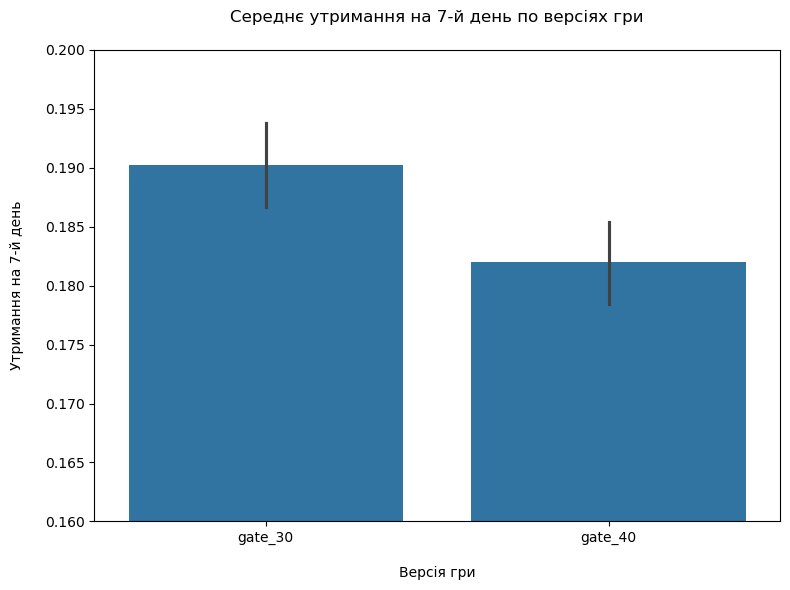

In [21]:
# Графік різниці середніх показників між групами
plt.figure(figsize=(8,6))
sns.barplot(x=df['version'], y=df['retention_7'])

plt.ylim(0.16, 0.20)
plt.title('Середнє утримання на 7-й день по версіях гри', pad=20)
plt.xlabel('Версія гри', labelpad=15)
plt.ylabel('Утримання на 7-й день', labelpad=15)
plt.tight_layout()
plt.show()

**Висновок:**

Cтовпчикова діаграма наочно показує, що версія gate_30 має кращий середній показник утримання. Це свідчить про те, що гравці, які отримали версію з воротами на 30-му рівні, залишаються у грі частіше на 7-й день, ніж ті, хто мав ворота на 40-му рівні.

**Формулювання нульової та альтернативної гіпотез:**

- Нульова гіпотеза $H_о$  :  немає різниці в утриманні між версіями gate_30 та gate_40.
- Альтернативна гіпотеза $H_a$ :   версія gate_30 має краще утримання користувачів на 7-й день після встановлення гри.

**3. Перевірка гіпотези (z-test)**

In [22]:
# Визначення груп
control = df[df['version'] == 'gate_30']
treatment = df[df['version'] == 'gate_40']

# Кількість успіхів та розмір вибірки
successes = np.array([control['retention_7'].sum(), treatment['retention_7'].sum()])
nobs = np.array([control['retention_7'].count(), treatment['retention_7'].count()])

# Z-тест
z_stat, pval = proportions_ztest(successes, nobs)

# Довірчі інтервали
ci_control = proportion_confint(successes[0], nobs[0], alpha=0.05)
ci_treatment = proportion_confint(successes[1], nobs[1], alpha=0.05)

# Вивід результатів
print(f"z-statistic: {z_stat:.3f}")
print(f"p-value: {pval:.3f}")
print(f"Довірчий інтервал 95% для групи control: [{ci_control[0]:.4f}, {ci_control[1]:.4f}]")
print(f"Довірчий інтервал 95% для групи treatment: [{ci_treatment[0]:.4f}, {ci_treatment[1]:.4f}]")

z-statistic: 3.164
p-value: 0.002
Довірчий інтервал 95% для групи control: [0.1866, 0.1938]
Довірчий інтервал 95% для групи treatment: [0.1785, 0.1855]


**Висновки:**

Статистична значущість різниці:
- z-statistic = 3.164.
- p-value = 0.002.

Оскільки 0.002 < 0.05, то нульова гіпотеза **відкидається**. Це означає, що різниця між утриманням користувачів у версіях gate_30 та gate_40 є статистично значущою. Тобто, версія gate_30 дійсно має краще утримання на 7-й день.

Перетин довірчих інтервалів:
- Для групи control (gate_30): [0.1866, 0.1938]
- Для групи treatment (gate_40): [0.1785, 0.1855]

Ці інтервали НЕ перетинаються - різниця між середніми показниками утримання є не лише статистично значущою, але й практично відчутною.

**4. Проводжу тест Хі-квадрат**

**Гіпотези:**

- Нульова гіпотеза $H_о$  : версія гри та утримання гравця на 7‑й день незалежні між собою.
- Альтернативна гіпотеза $H_a$ : існує залежність між версією гри та утриманням гравця на 7‑й день.

In [23]:
crosstab = pd.crosstab(df['version'], df['retention_7'])

# Хі-квадрат тест
chi2, p_val, dof, expected = stats.chi2_contingency(crosstab)

print(f"χ² = {chi2:.3f}")
print(f"p-value = {p_val:.3f}")
print(f"Ступені свободи = {dof}")
print("Очікувані частоти:\n", expected)

χ² = 9.959
p-value = 0.002
Ступені свободи = 1
Очікувані частоти:
 [[36382.90257127  8317.09742873]
 [37025.09742873  8463.90257127]]


**Висновок:**

Оскільки 0.002 < 0.05, нульова гіпотеза **відкидається**. Це означає, що існує статистично значуща залежність між версією гри та утриманням користувачів на 7-й день. Версія gate_30 показує вищий рівень утримання, ніж gate_40, і ця різниця не є випадковою.

Тест Хі‑квадрат також підтвердив, що зміна розташування воріт у грі впливає на поведінку користувачів. Версія gate_30 має кращий показник утримання користувачів на 7-й день.